# DBSCAN Algorithm Explained: Discover Density-Based Clustering Techniques | Unsupervised Learning

This notebook walks through **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** with hands-on Python code examples using `scikit-learn`.

**Contents:**
1. Import libraries
2. Generate sample datasets
3. Apply DBSCAN
4. Visualize clusters & noise points
5. Effect of `eps` and `min_samples`
6. DBSCAN vs K-Means comparison
7. Evaluating clusters (Silhouette Score)


## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

%matplotlib inline


## 2. Generate Sample Dataset

We'll use `make_moons` since it creates non-spherical, crescent-shaped clusters — perfect for showing why DBSCAN outperforms K-Means here.

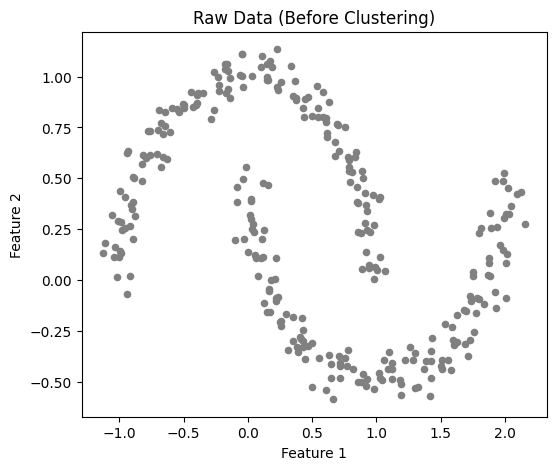

In [2]:
X, y = make_moons(n_samples=300, noise=0.06, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20, color='gray')
plt.title("Raw Data (Before Clustering)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 3. Apply DBSCAN

In [3]:
# eps: max distance between two samples to be considered neighbors
# min_samples: minimum number of points to form a dense region (core point)
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")


Estimated number of clusters: 2
Estimated number of noise points: 0


## 4. Visualize Clusters & Noise Points

Points labeled `-1` by DBSCAN are considered **noise/outliers** and are usually plotted separately (e.g. in black).

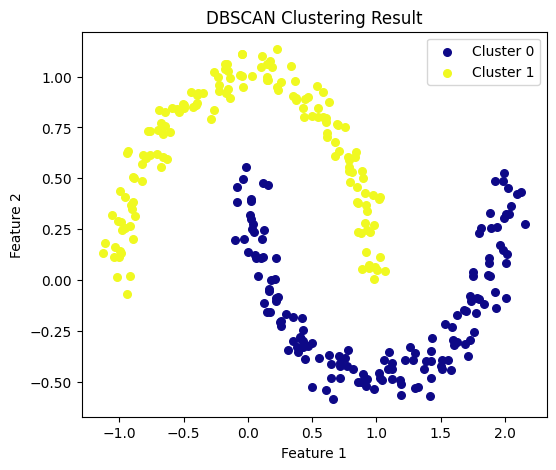

In [4]:
plt.figure(figsize=(6, 5))
unique_labels = set(labels)
colors = plt.cm.plasma(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'black'  # noise points
        marker = 'x'
        label_name = 'Noise'
    else:
        marker = 'o'
        label_name = f'Cluster {label}'

    mask = labels == label
    plt.scatter(X[mask, 0], X[mask, 1], c=[color], marker=marker, s=30, label=label_name)

plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


## 5. Effect of `eps` and `min_samples`

DBSCAN's results are highly sensitive to these two parameters. Let's compare a few combinations side by side.

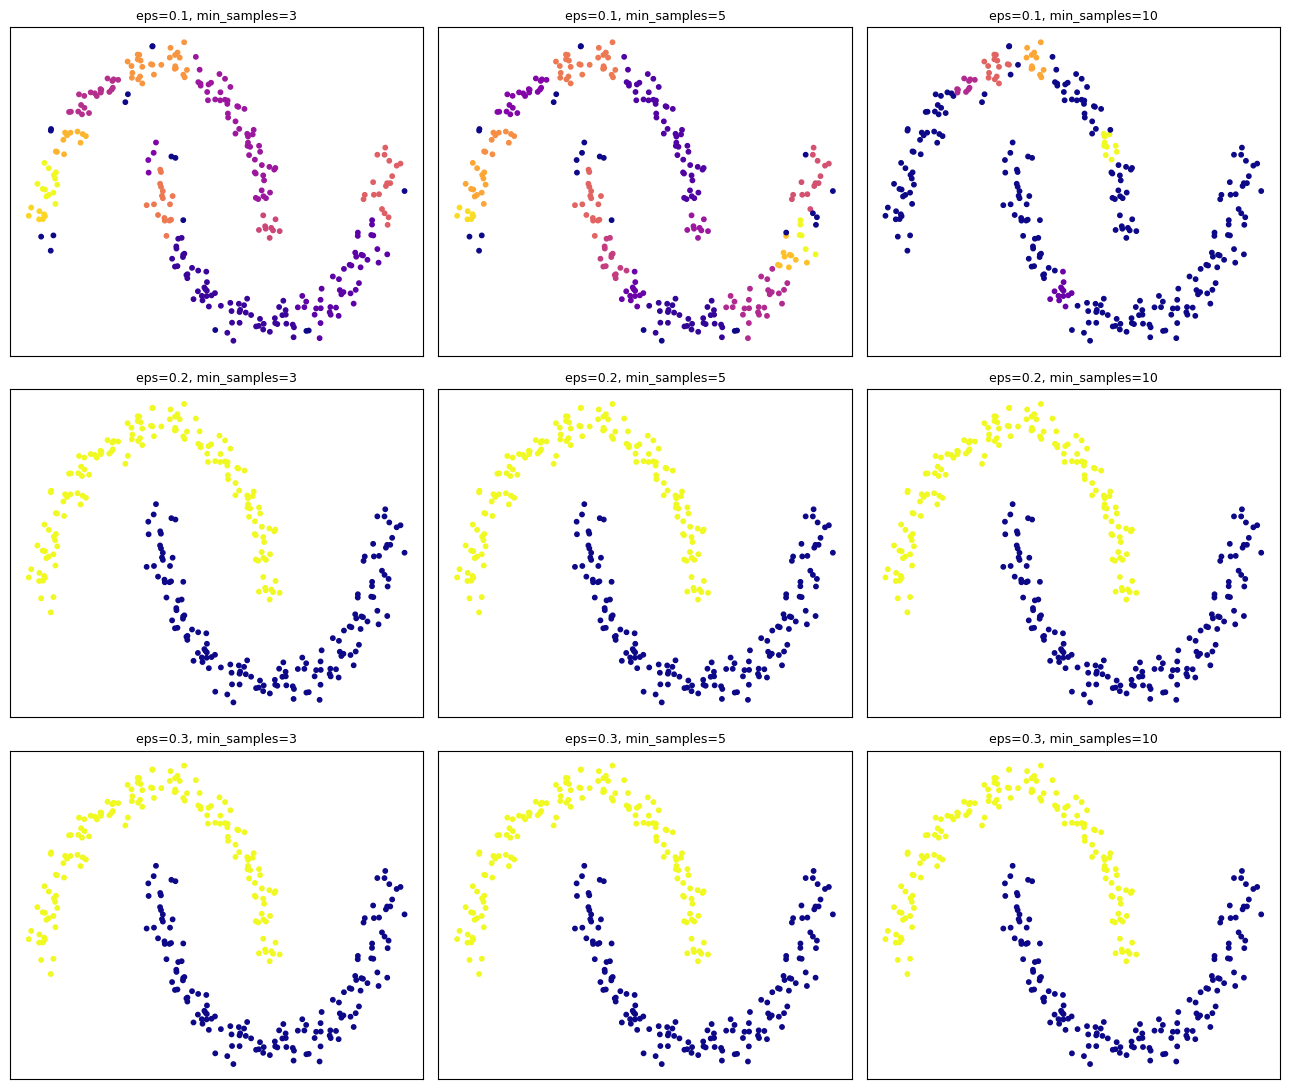

In [5]:
eps_values = [0.1, 0.2, 0.3]
min_samples_values = [3, 5, 10]

fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(13, 11))

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        lbls = db.fit_predict(X)
        ax = axes[i, j]
        ax.scatter(X[:, 0], X[:, 1], c=lbls, cmap='plasma', s=10)
        ax.set_title(f"eps={eps}, min_samples={min_samples}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


## 6. DBSCAN vs K-Means

K-Means assumes spherical clusters, so it struggles with the crescent-moon shapes. DBSCAN handles them correctly.

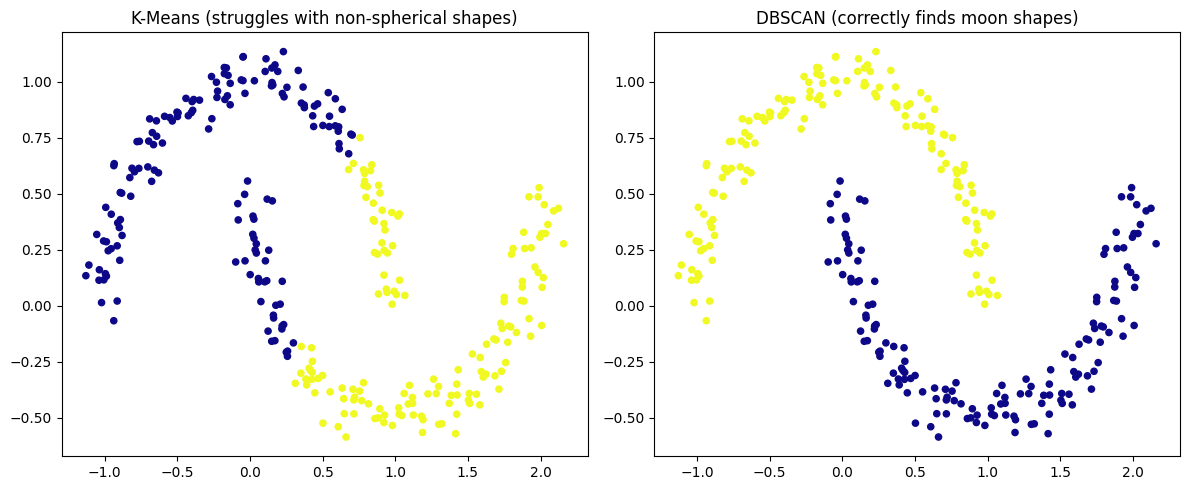

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means
km = KMeans(n_clusters=2, n_init=10, random_state=42)
km_labels = km.fit_predict(X)
axes[0].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='plasma', s=20)
axes[0].set_title("K-Means (struggles with non-spherical shapes)")

# DBSCAN
db = DBSCAN(eps=0.2, min_samples=5)
db_labels = db.fit_predict(X)
axes[1].scatter(X[:, 0], X[:, 1], c=db_labels, cmap='plasma', s=20)
axes[1].set_title("DBSCAN (correctly finds moon shapes)")

plt.tight_layout()
plt.show()


## 7. Evaluating Clusters — Silhouette Score

A higher silhouette score (closer to 1) indicates better-defined clusters. Note: noise points (`-1`) are usually excluded from this calculation.

In [7]:
mask = db_labels != -1  # exclude noise
if len(set(db_labels[mask])) > 1:
    score = silhouette_score(X[mask], db_labels[mask])
    print(f"Silhouette Score (DBSCAN, excluding noise): {score:.3f}")
else:
    print("Not enough clusters to compute silhouette score.")


Silhouette Score (DBSCAN, excluding noise): 0.330


## Summary

- DBSCAN groups points based on **density**, not distance to a centroid.
- It automatically detects the number of clusters and flags outliers as noise.
- `eps` and `min_samples` are the two key hyperparameters to tune.
- It outperforms K-Means on datasets with **non-spherical / irregular shaped clusters**.

---
*#MachineLearning #UnsupervisedLearning #DBSCAN #Clustering #DataScience*
